# Faz 2: Veri Gorsellestirme

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
import os

warnings.filterwarnings("ignore")
plt.rcParams["figure.dpi"] = 150

pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 100)
pd.set_option("display.float_format", lambda x: "%.3f" % x)

DATA_DIR = "../data"
FIGURES_DIR = "../outputs/figures"
os.makedirs(FIGURES_DIR, exist_ok=True)

# Pickle dosyalarindan oku
df_tahsilat = pd.read_pickle(os.path.join(DATA_DIR, "tahsilat.pkl"))
df_tahsilat_1 = pd.read_pickle(os.path.join(DATA_DIR, "tahsilat_1.pkl"))
df_tahakkuk = pd.read_pickle(os.path.join(DATA_DIR, "tahakkuk.pkl"))
df_tahakkuk_1 = pd.read_pickle(os.path.join(DATA_DIR, "tahakkuk_1.pkl"))
df_tahakkuk_2 = pd.read_pickle(os.path.join(DATA_DIR, "tahakkuk_2.pkl"))

# Tahakkuk birlestirme ve tarih donusumu
df_tahakkuk_all = pd.concat([df_tahakkuk, df_tahakkuk_1, df_tahakkuk_2], ignore_index=True)
for df_tmp in [df_tahakkuk, df_tahakkuk_1, df_tahakkuk_2, df_tahakkuk_all]:
    df_tmp["mali_yil_donem"] = pd.to_datetime(df_tmp["mali_yil_donem"])
df_tahakkuk_all["ay"] = df_tahakkuk_all["mali_yil_donem"].dt.month

AY_ISIMLERI = {1:"Oca", 2:"Sub", 3:"Mar", 4:"Nis", 5:"May", 6:"Haz",
               7:"Tem", 8:"Agu", 9:"Eyl", 10:"Eki", 11:"Kas", 12:"Ara"}

print("Veri yuklendi.")
print(f"Tahakkuk (birlesik): {df_tahakkuk_all.shape}")
print(f"Tahsilat: {df_tahsilat.shape}")
print(f"Tahsilat 1: {df_tahsilat_1.shape}")

Veri yuklendi.
Tahakkuk (birlesik): (1185698, 11)
Tahsilat: (636993, 9)
Tahsilat 1: (917632, 22)


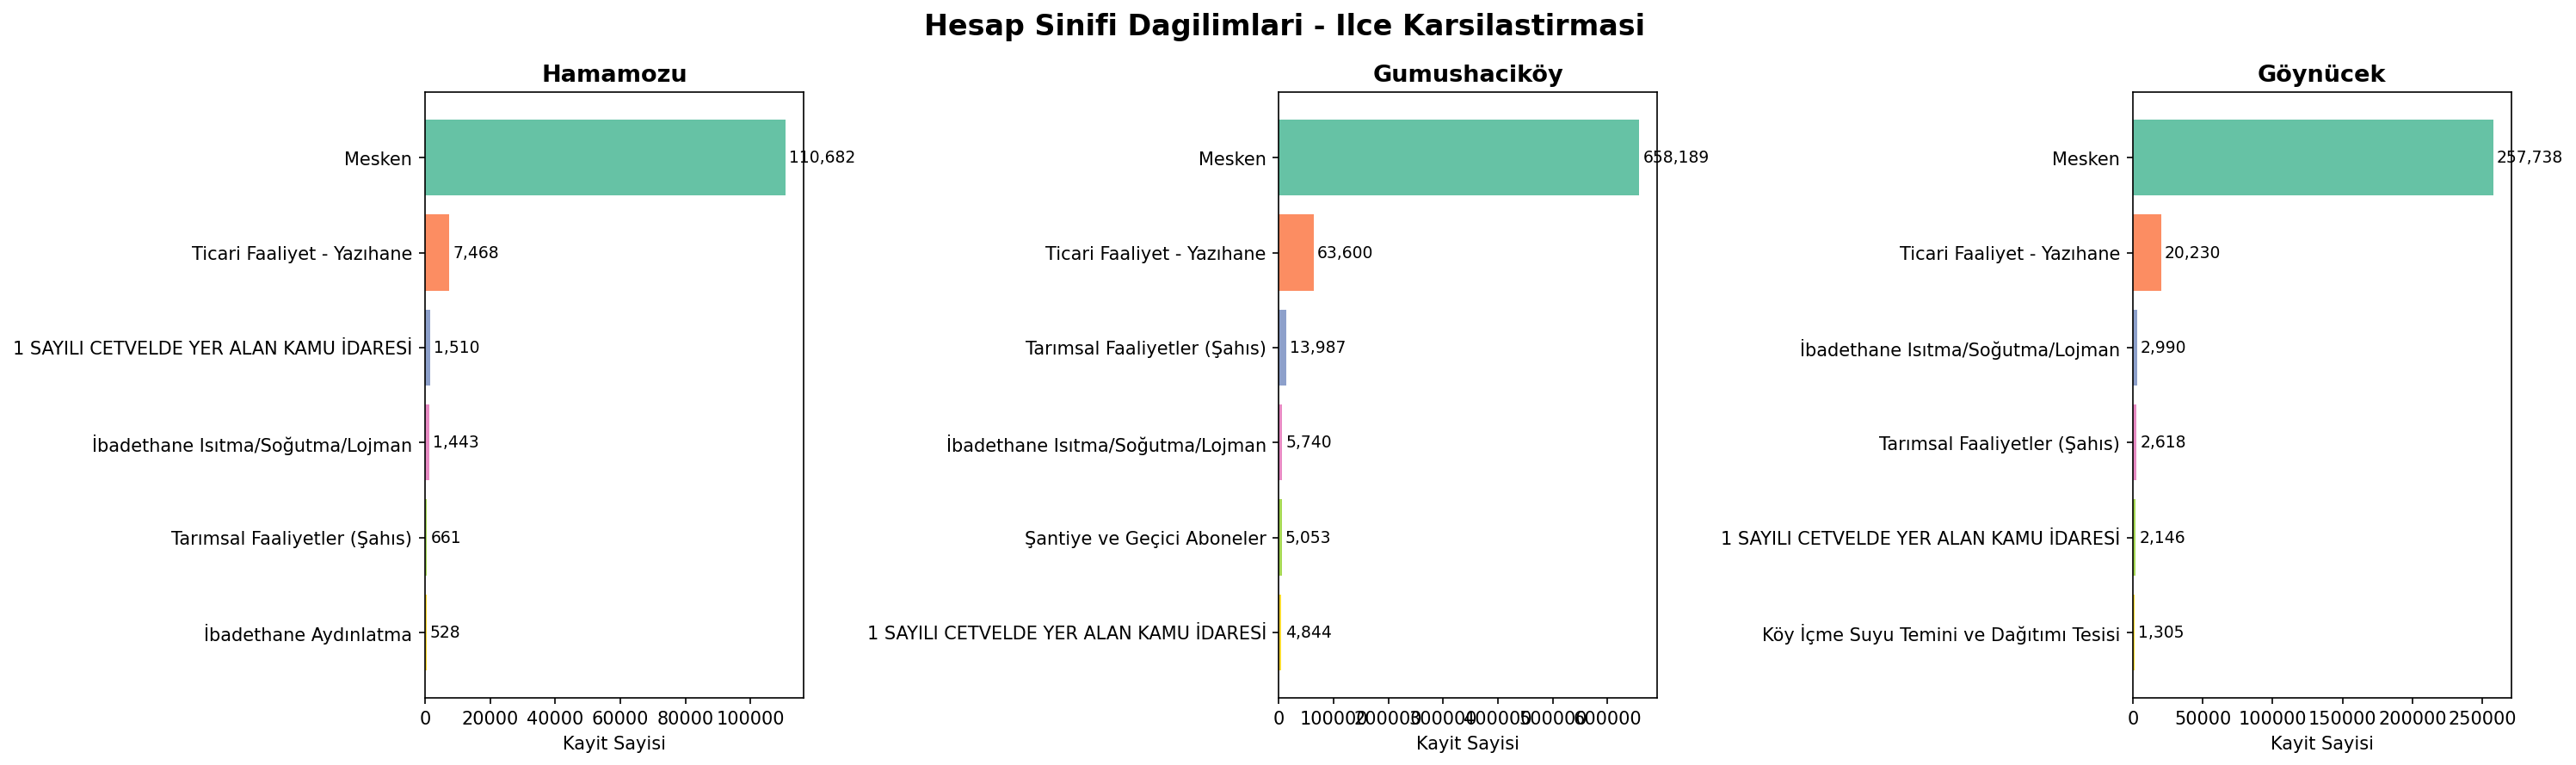

In [2]:
# 2.1 Hesap Sinifi Dagilimlari (3 Ilce Subplot)
fig, axes = plt.subplots(1, 3, figsize=(20, 6))
fig.suptitle("Hesap Sinifi Dagilimlari - Ilce Karsilastirmasi", fontsize=16, fontweight="bold")

ilce_data = [
    (df_tahakkuk, "Hamamozu"),
    (df_tahakkuk_1, "Gumushaciköy"),
    (df_tahakkuk_2, "Göynücek")
]

for ax, (df, ilce_adi) in zip(axes, ilce_data):
    top_siniflar = df["Hesap Sınıfı"].value_counts().head(6)
    bars = ax.barh(top_siniflar.index, top_siniflar.values, color=sns.color_palette("Set2", len(top_siniflar)))
    ax.set_title(ilce_adi, fontsize=13, fontweight="bold")
    ax.set_xlabel("Kayit Sayisi")
    ax.invert_yaxis()
    for bar, val in zip(bars, top_siniflar.values):
        ax.text(val + max(top_siniflar.values) * 0.01, bar.get_y() + bar.get_height() / 2,
                f"{val:,}", va="center", fontsize=9)

plt.tight_layout()
plt.savefig(f"{FIGURES_DIR}/hesap_sinifi_dagilimi.png", dpi=150, bbox_inches="tight")
plt.show()

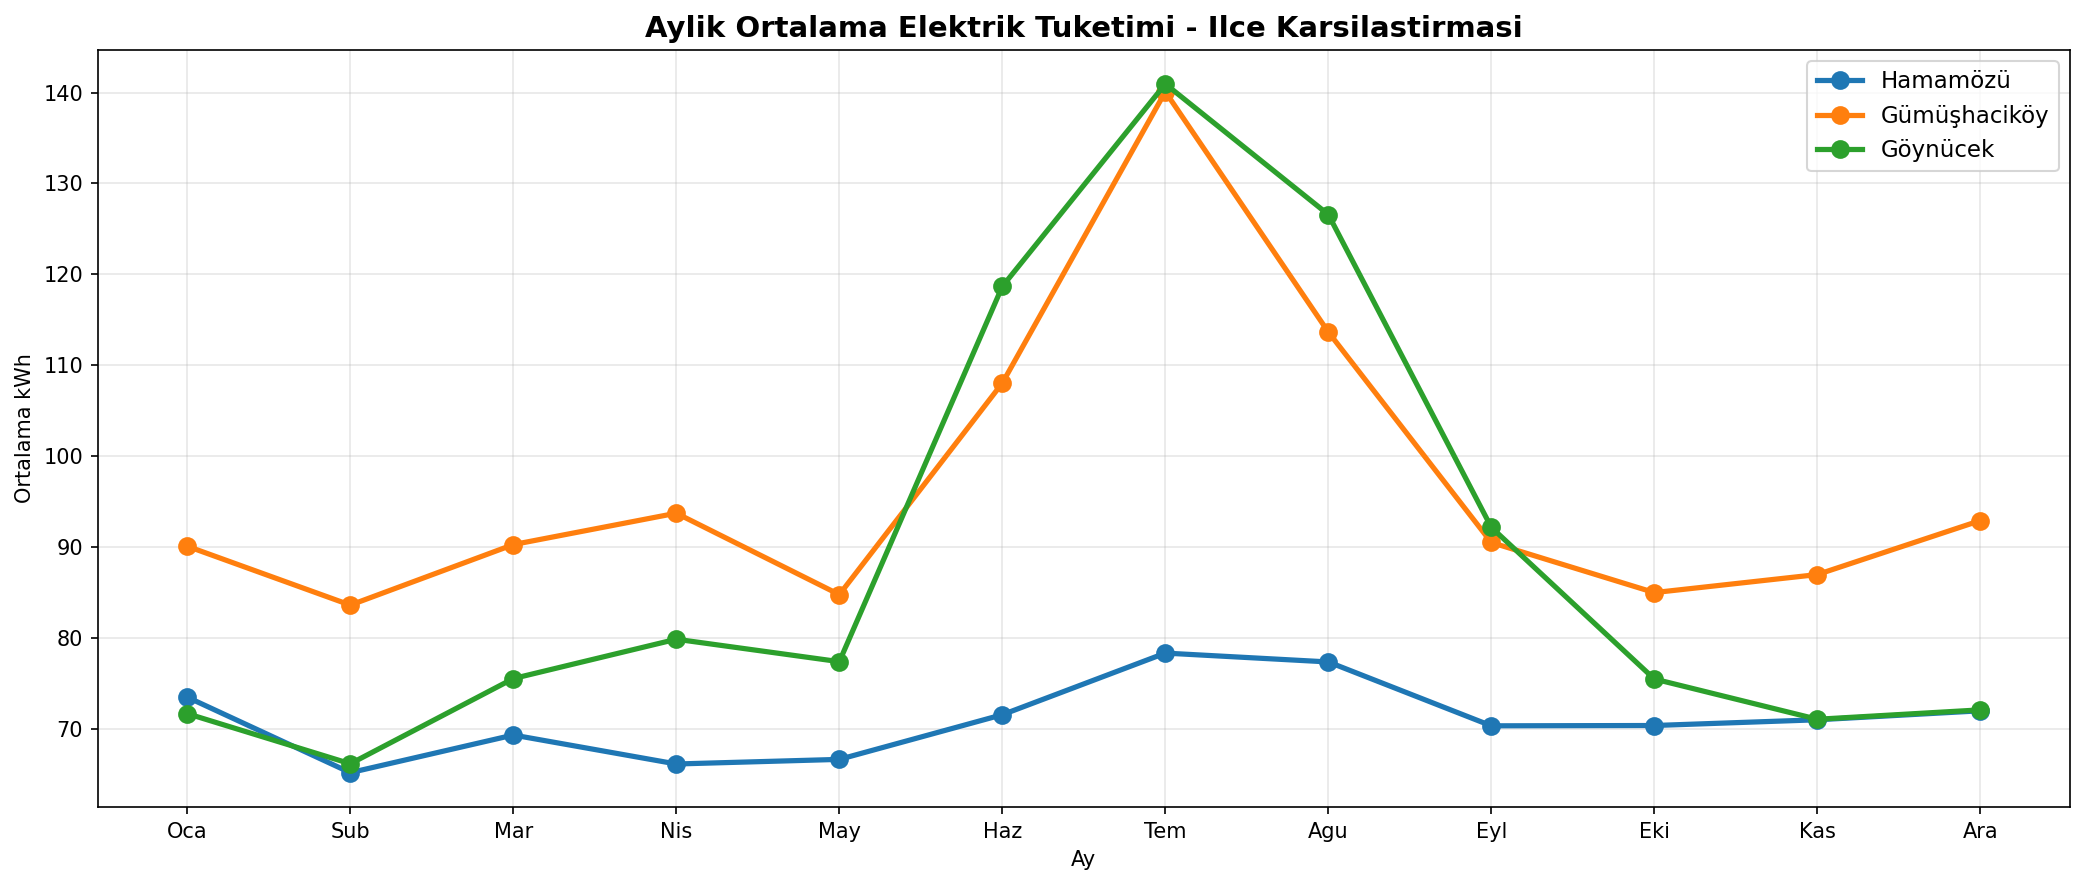

In [3]:
# 2.2 Aylik Ortalama Tuketim Trendi (Cizgi Grafigi)
aylik_ort = df_tahakkuk_all.groupby(["ilce", "ay"])["kwh"].mean().reset_index()

fig, ax = plt.subplots(figsize=(14, 6))
for ilce in ["HAMAMÖZÜ", "GÜMÜŞHACIKÖY", "GÖYNÜCEK"]:
    data = aylik_ort[aylik_ort["ilce"] == ilce].sort_values("ay")
    ax.plot(data["ay"], data["kwh"], marker="o", linewidth=2.5, markersize=8, label=ilce.title())

ax.set_xticks(range(1, 13))
ax.set_xticklabels([AY_ISIMLERI[i] for i in range(1, 13)])
ax.set_xlabel("Ay")
ax.set_ylabel("Ortalama kWh")
ax.set_title("Aylik Ortalama Elektrik Tuketimi - Ilce Karsilastirmasi", fontsize=14, fontweight="bold")
ax.legend(fontsize=11)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(f"{FIGURES_DIR}/aylik_tuketim_trendi.png", dpi=150, bbox_inches="tight")
plt.show()

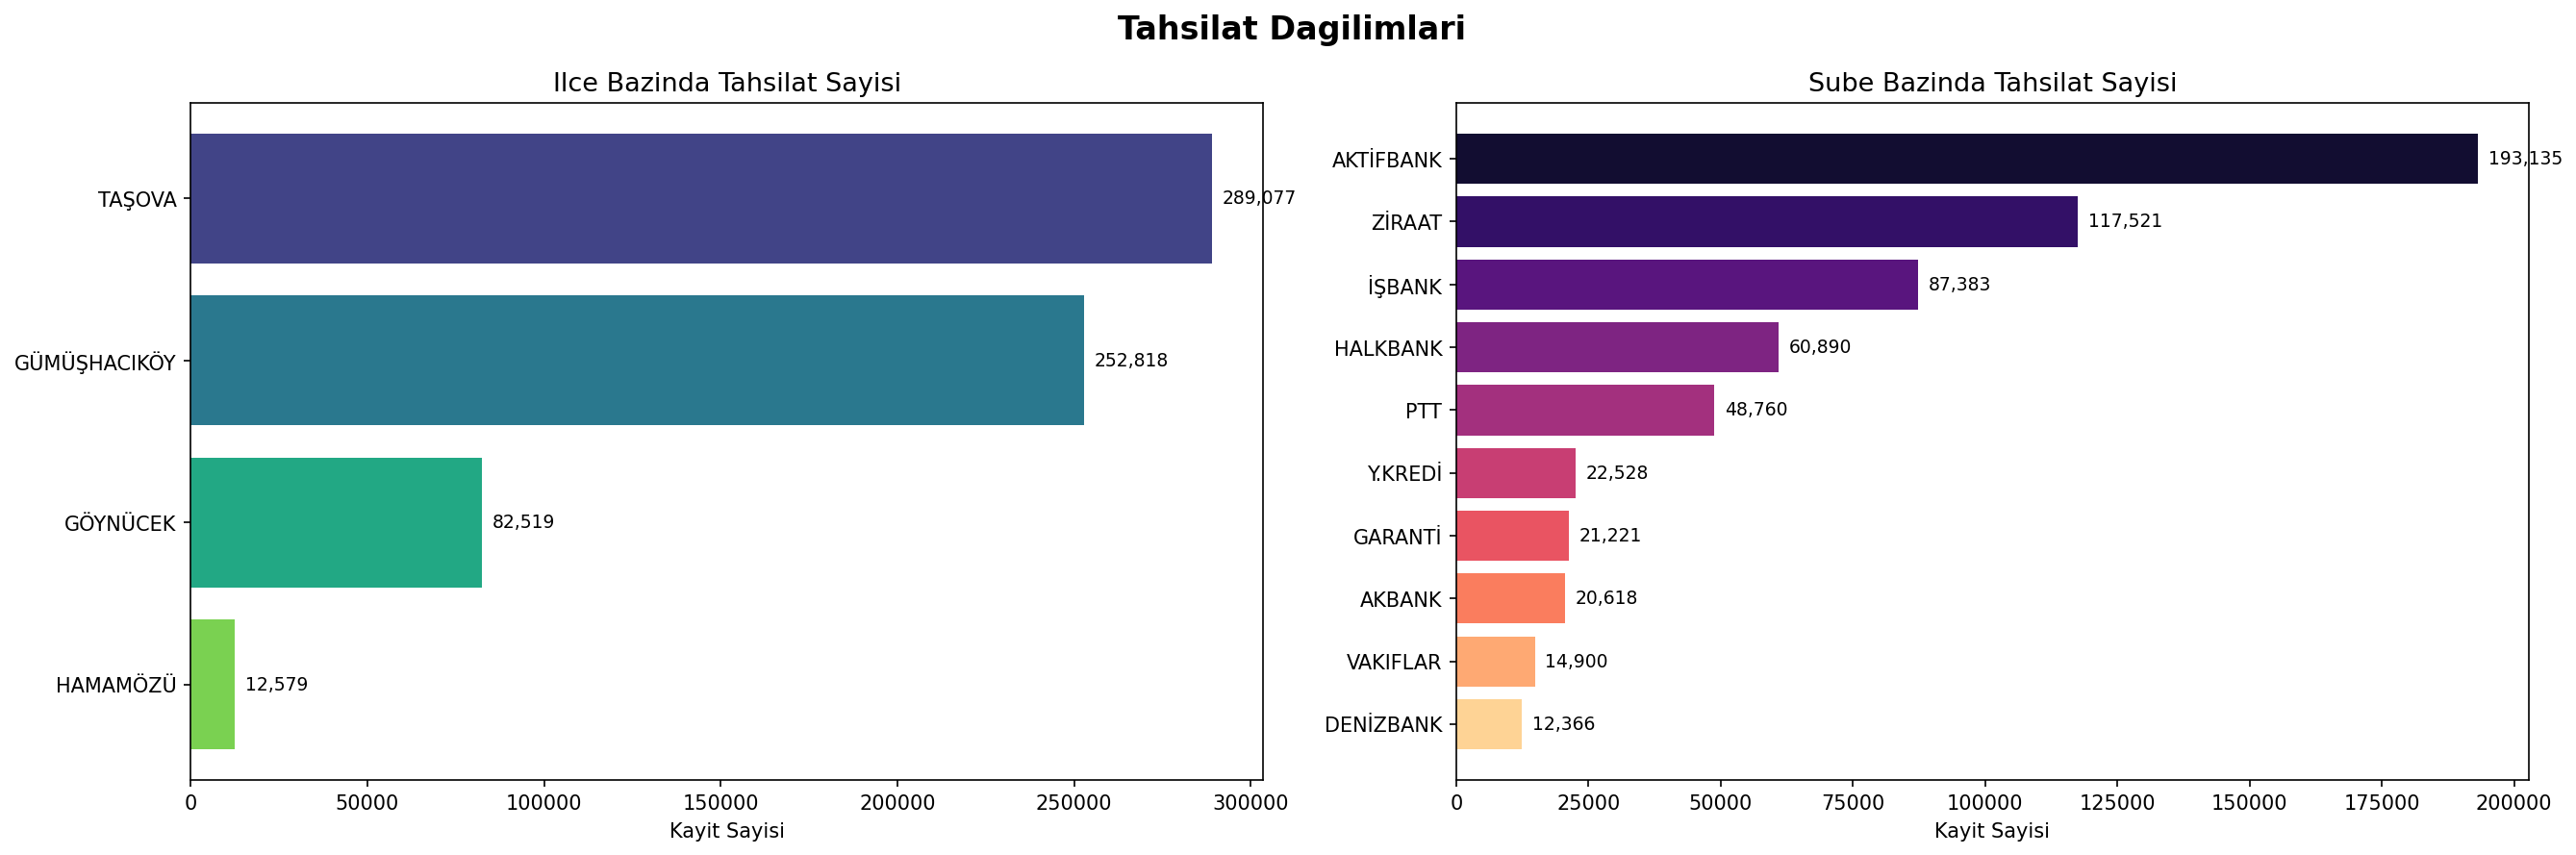

In [4]:
# 2.3 Tahsilat Ilce ve Sube Dagilimlari
fig, axes = plt.subplots(1, 2, figsize=(18, 6))
fig.suptitle("Tahsilat Dagilimlari", fontsize=16, fontweight="bold")

# Ilce dagilimi
ilce_dagilim = df_tahsilat["İlçe"].value_counts().head(10)
bars1 = axes[0].barh(ilce_dagilim.index, ilce_dagilim.values, color=sns.color_palette("viridis", len(ilce_dagilim)))
axes[0].set_title("Ilce Bazinda Tahsilat Sayisi", fontsize=13)
axes[0].set_xlabel("Kayit Sayisi")
axes[0].invert_yaxis()
for bar, val in zip(bars1, ilce_dagilim.values):
    axes[0].text(val + max(ilce_dagilim.values) * 0.01, bar.get_y() + bar.get_height() / 2,
                 f"{val:,}", va="center", fontsize=9)

# Sube dagilimi
sube_dagilim = df_tahsilat["Şube"].value_counts().head(10)
bars2 = axes[1].barh(sube_dagilim.index, sube_dagilim.values, color=sns.color_palette("magma", len(sube_dagilim)))
axes[1].set_title("Sube Bazinda Tahsilat Sayisi", fontsize=13)
axes[1].set_xlabel("Kayit Sayisi")
axes[1].invert_yaxis()
for bar, val in zip(bars2, sube_dagilim.values):
    axes[1].text(val + max(sube_dagilim.values) * 0.01, bar.get_y() + bar.get_height() / 2,
                 f"{val:,}", va="center", fontsize=9)

plt.tight_layout()
plt.savefig(f"{FIGURES_DIR}/tahsilat_ilce_sube.png", dpi=150, bbox_inches="tight")
plt.show()

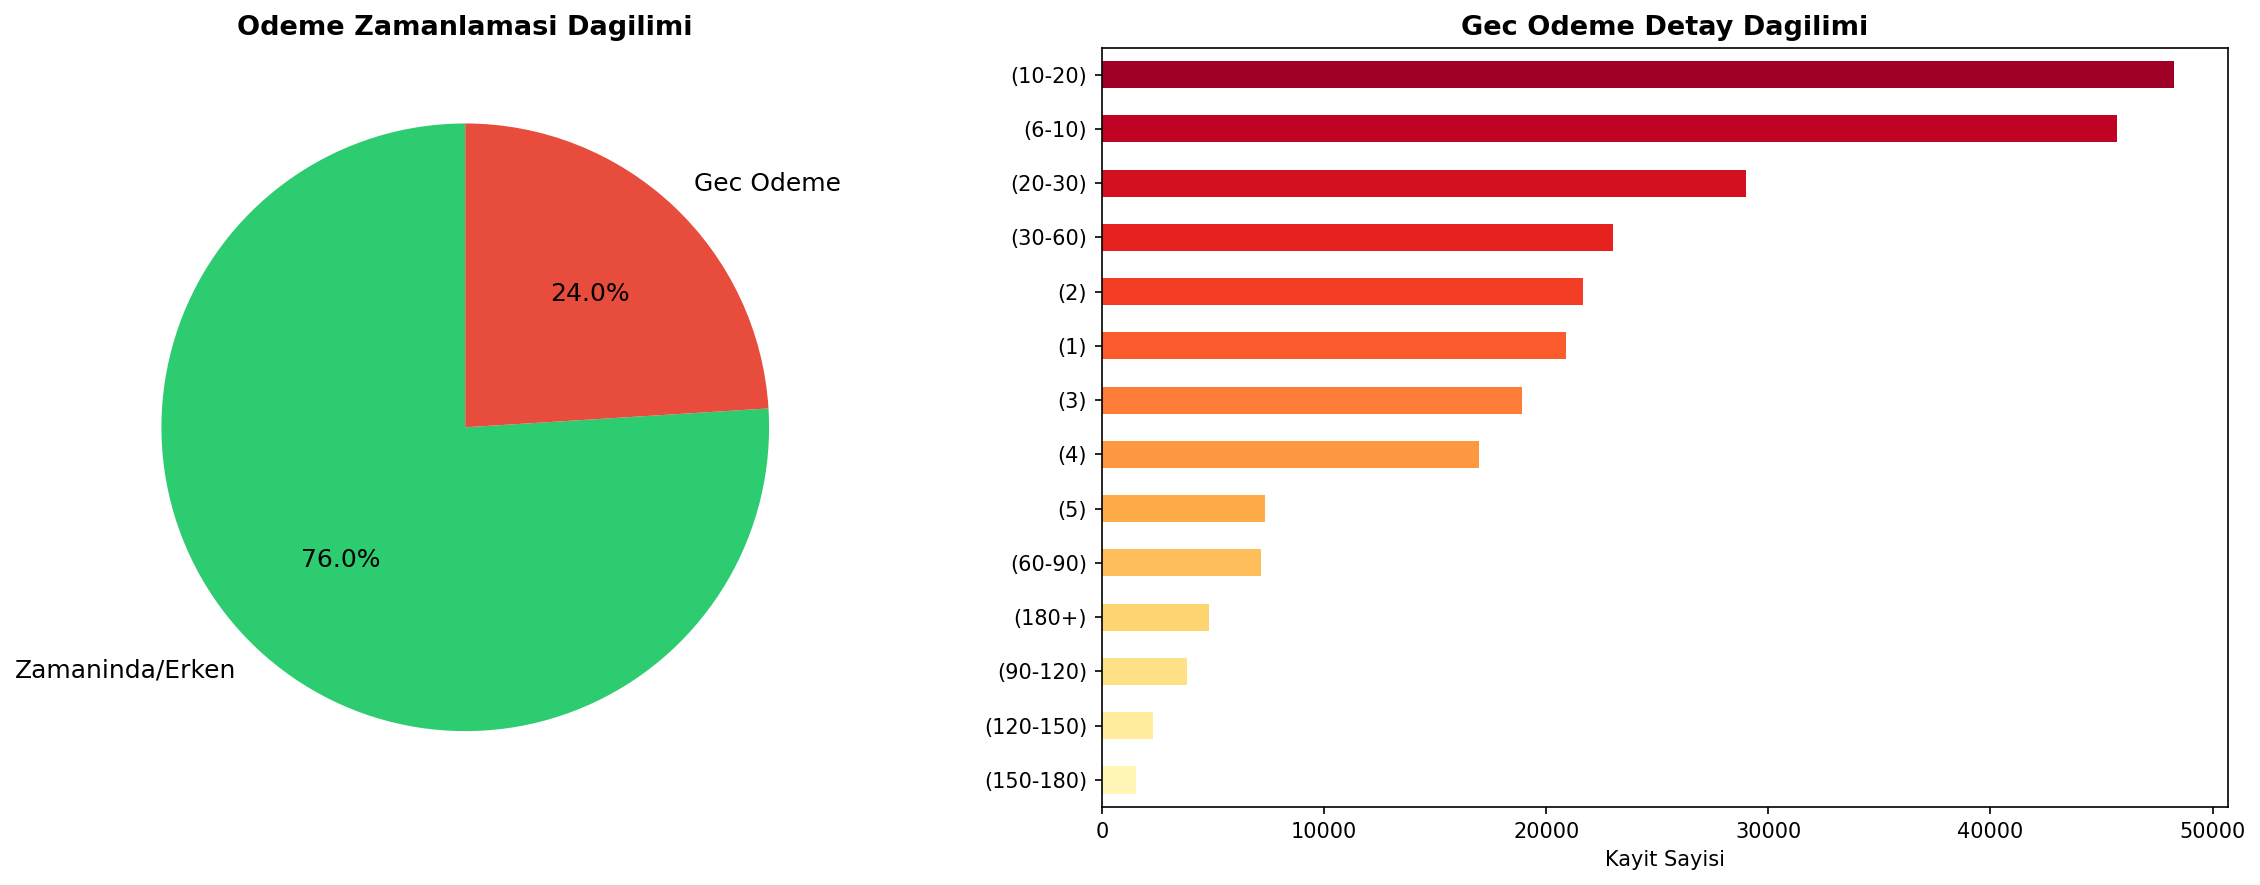

In [5]:
# 2.4 Zamaninda vs Gec Odeme Oranlari
zamaninda = (
    df_tahsilat_1["Son Ödeme Tarihinden Önceki Tahsilat"].notna() |
    df_tahsilat_1["Son Ödeme Tarihindeki Tahsilat"].notna()
)
gec_sutunlar = [col for col in df_tahsilat_1.columns if col.startswith("Son Ödeme (")]
gec_odeme = df_tahsilat_1[gec_sutunlar].notna().any(axis=1)

zamaninda_sayisi = zamaninda.sum()
gec_sayisi = gec_odeme.sum()

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Pasta grafigi
axes[0].pie([zamaninda_sayisi, gec_sayisi],
            labels=["Zamaninda/Erken", "Gec Odeme"],
            autopct="%1.1f%%", colors=["#2ecc71", "#e74c3c"],
            startangle=90, textprops={"fontsize": 12})
axes[0].set_title("Odeme Zamanlamasi Dagilimi", fontsize=13, fontweight="bold")

# Gec odeme detay
gec_detay = {col.replace("Son Ödeme ", ""): df_tahsilat_1[col].notna().sum() for col in gec_sutunlar}
gec_df = pd.Series(gec_detay).sort_values(ascending=True)
gec_df.plot(kind="barh", ax=axes[1], color=sns.color_palette("YlOrRd", len(gec_df)))
axes[1].set_title("Gec Odeme Detay Dagilimi", fontsize=13, fontweight="bold")
axes[1].set_xlabel("Kayit Sayisi")

plt.tight_layout()
plt.savefig(f"{FIGURES_DIR}/odeme_zamanlama.png", dpi=150, bbox_inches="tight")
plt.show()

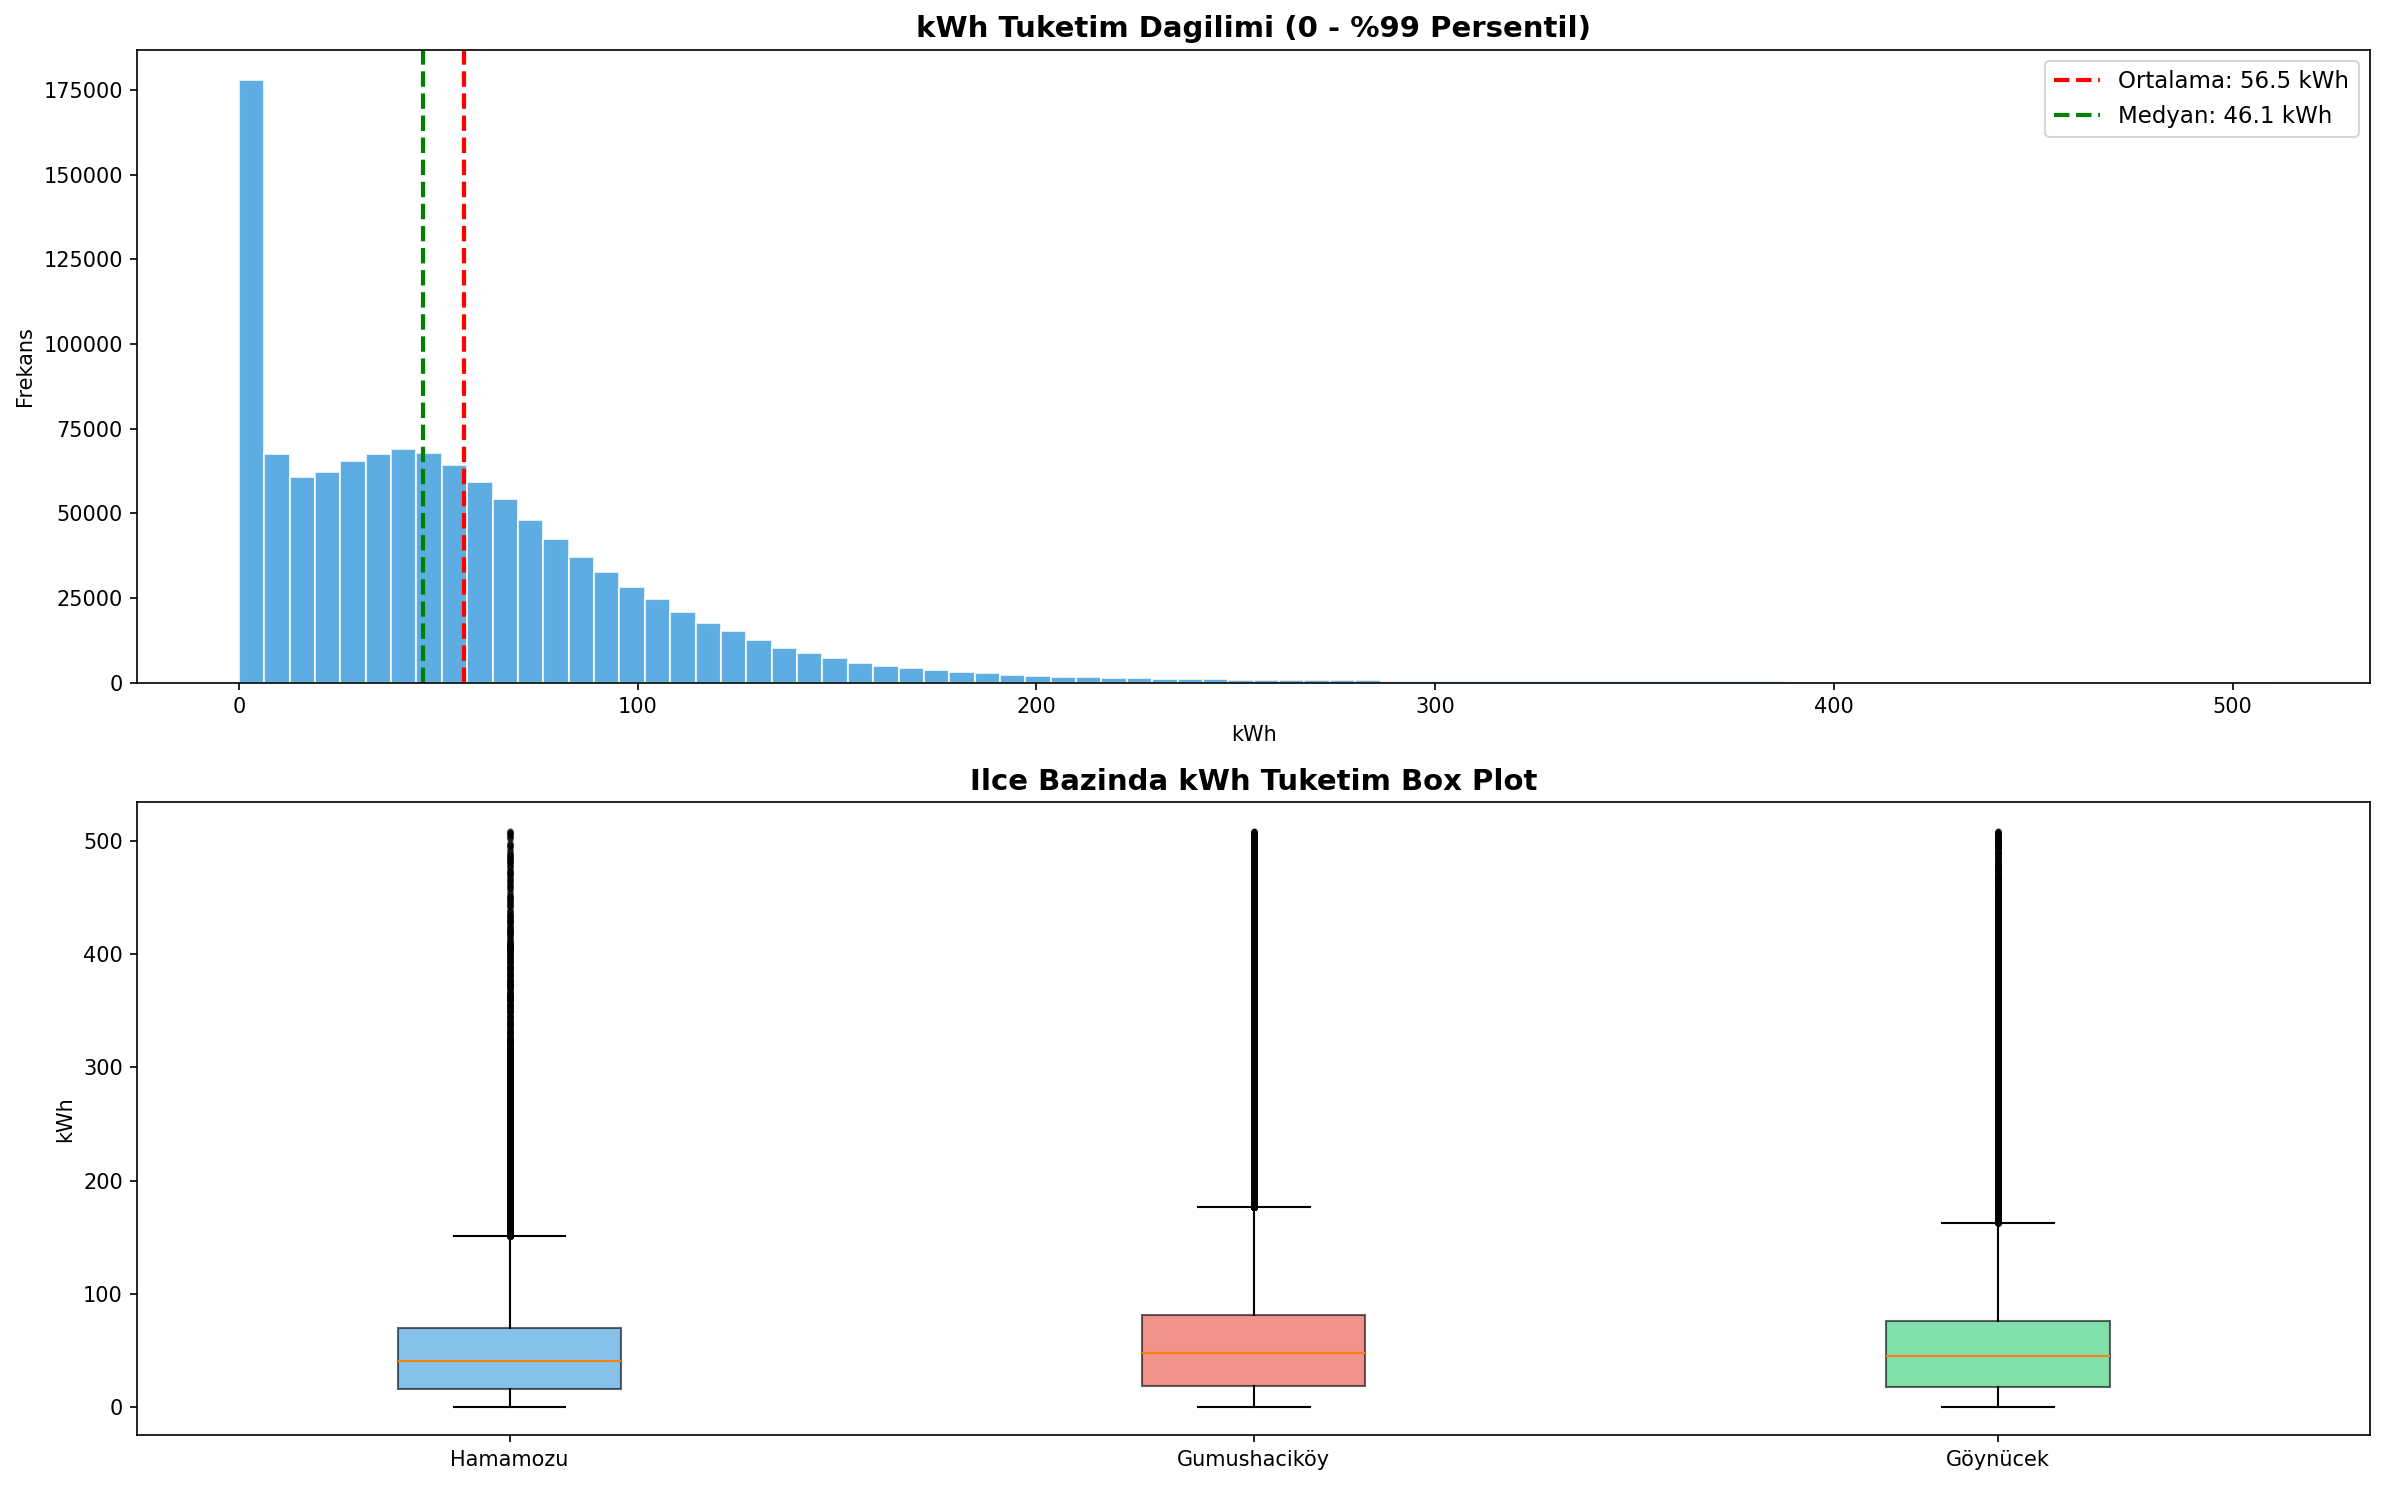

In [6]:
# 2.5 kWh Tuketim Dagilimi (Histogram + Box Plot)
upper_limit = df_tahakkuk_all["kwh"].quantile(0.99)
kwh_filtered = df_tahakkuk_all[df_tahakkuk_all["kwh"].between(0, upper_limit)]["kwh"]

fig, axes = plt.subplots(2, 1, figsize=(16, 10))

# Histogram
axes[0].hist(kwh_filtered, bins=80, color="#3498db", edgecolor="white", alpha=0.8)
axes[0].axvline(kwh_filtered.mean(), color="red", linestyle="--", linewidth=2, label=f"Ortalama: {kwh_filtered.mean():.1f} kWh")
axes[0].axvline(kwh_filtered.median(), color="green", linestyle="--", linewidth=2, label=f"Medyan: {kwh_filtered.median():.1f} kWh")
axes[0].set_title("kWh Tuketim Dagilimi (0 - %99 Persentil)", fontsize=14, fontweight="bold")
axes[0].set_xlabel("kWh")
axes[0].set_ylabel("Frekans")
axes[0].legend(fontsize=11)

# Box Plot - ilce bazli
box_data = [df_tmp[df_tmp["kwh"].between(0, upper_limit)]["kwh"]
            for df_tmp in [df_tahakkuk, df_tahakkuk_1, df_tahakkuk_2]]
box_labels = ["Hamamozu", "Gumushaciköy", "Göynücek"]

bp = axes[1].boxplot(box_data, labels=box_labels, patch_artist=True,
                     showfliers=True, flierprops=dict(marker="o", markersize=2, alpha=0.3))
for patch, color in zip(bp["boxes"], ["#3498db", "#e74c3c", "#2ecc71"]):
    patch.set_facecolor(color)
    patch.set_alpha(0.6)

axes[1].set_title("Ilce Bazinda kWh Tuketim Box Plot", fontsize=14, fontweight="bold")
axes[1].set_ylabel("kWh")

plt.tight_layout()
plt.savefig(f"{FIGURES_DIR}/kwh_dagilim.png", dpi=150, bbox_inches="tight")
plt.show()